In [ ]:
import math
import os
from itertools import combinations
from collections import Counter
import pandas
import pandas as pd
import torch
import tqdm
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import pandas as pd
meta_df = pd.read_csv('data/meta/bing.csv', sep = ',')
meta_df

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 8. Stacked Bar Chart of Image Dimensions by Class
plt.figure(figsize=(14, 10))

# Define resolution categories
def categorize_resolution(width, height):
    pixels = width * height
    if pixels < 0.5 * 1_000_000:
        return 'Small (<0.5MP)'
    elif pixels < 1 * 1_000_000:
        return 'Medium (0.5-1MP)'
    elif pixels < 2 * 1_000_000:
        return 'Large (1-2MP)'
    elif pixels < 5 * 1_000_000:
        return 'X-Large (2-5MP)'
    else:
        return 'XX-Large (>5MP)'

# Create a dictionary to store results
resolution_by_class = {}
categories = ['Small (<0.5MP)', 'Medium (0.5-1MP)', 'Large (1-2MP)',
              'X-Large (2-5MP)', 'XX-Large (>5MP)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
classes = meta_df['klass'].unique()

for cls in classes:
    subset = meta_df[meta_df['klass'] == cls]
    resolutions = [categorize_resolution(w, h) for w, h in zip(subset['width'], subset['height'])]
    counts = [resolutions.count(cat) for cat in categories]
    resolution_by_class[cls] = counts

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
bottom = np.zeros(len(classes))

for i, cat in enumerate(categories):
    values = [resolution_by_class[cls][i] for cls in classes]
    ax.bar(classes, values, bottom=bottom, label=cat, color=colors[i], alpha=0.7,
          edgecolor='black', linewidth=0.5)
    bottom += values

ax.set_title('Image Resolution Categories by Class', fontsize=16)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.legend(title='Resolution Category', fontsize=10)

# Add total counts on top of each bar
for i, cls in enumerate(classes):
    total = sum(resolution_by_class[cls])
    ax.text(i, total + 5, f'Total: {total}', ha='center', fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 6. Heatmap of Image Resolution Distribution
plt.figure(figsize=(12, 10))

# Define resolution bins
width_bins = np.linspace(meta_df['width'].min(), meta_df['width'].max(), 20)
height_bins = np.linspace(meta_df['height'].min(), meta_df['height'].max(), 20)

# Create a 2D histogram
hist, xedges, yedges = np.histogram2d(
    meta_df['width'], meta_df['height'],
    bins=[width_bins, height_bins]
)

# Create a heatmap
plt.imshow(hist.T, origin='lower', aspect='auto', cmap='viridis',
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])

plt.colorbar(label='Number of Images')
plt.title('Heatmap of Image Resolutions', fontsize=16)
plt.xlabel('Width (pixels)', fontsize=12)
plt.ylabel('Height (pixels)', fontsize=12)

# Add diagonal line to represent square images
max_dim = max(meta_df['width'].max(), meta_df['height'].max())
plt.plot([0, max_dim], [0, max_dim], 'r--', label='Square (1:1)', linewidth=2)
plt.legend()

plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 5. Box Plot of Image Dimensions by Class
plt.figure(figsize=(14, 10))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Width by class
classes = meta_df['klass'].unique()
width_by_class = [meta_df[meta_df['klass'] == cls]['width'] for cls in classes]
ax1.boxplot(width_by_class, labels=classes, patch_artist=True,
           boxprops=dict(facecolor='#1f77b4', alpha=0.7),
           medianprops=dict(color='red'))
ax1.set_title('Width Distribution by Class', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Width (pixels)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Height by class
height_by_class = [meta_df[meta_df['klass'] == cls]['height'] for cls in classes]
ax2.boxplot(height_by_class, labels=classes, patch_artist=True,
           boxprops=dict(facecolor='#ff7f0e', alpha=0.7),
           medianprops=dict(color='red'))
ax2.set_title('Height Distribution by Class', fontsize=14)
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Height (pixels)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 4. Image Aspect Ratio Analysis
plt.figure(figsize=(12, 8))

# Calculate aspect ratios
aspect_ratios = meta_df['width'] / meta_df['height']

# Plot histogram with KDE
plt.hist(aspect_ratios, bins=30, alpha=0.7, color='#2ca02c',
         edgecolor='black', linewidth=0.8)

plt.axvline(x=1.0, color='red', linestyle='--',
            linewidth=2, label='Square (1:1)')

plt.title('Distribution of Image Aspect Ratios', fontsize=16)
plt.xlabel('Aspect Ratio (Width/Height)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

# 1. Class Distribution - Pie Chart
plt.figure(figsize=(10, 8))
class_counts = meta_df['klass'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
        startangle=90, shadow=True, explode=[0.05]*len(class_counts),
        textprops={'fontsize': 12})
plt.title('Distribution of Classes', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 2. Image Dimensions Scatter Plot with Color by Class
plt.figure(figsize=(12, 8))
classes = meta_df['klass'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
for i, cls in enumerate(classes):
    subset = meta_df[meta_df['klass'] == cls]
    plt.scatter(subset['width'], subset['height'],
                alpha=0.7, label=cls, color=colors[i % len(colors)])

plt.xlabel('Width (pixels)', fontsize=12)
plt.ylabel('Height (pixels)', fontsize=12)
plt.title('Image Dimensions by Class', fontsize=16)
plt.legend(title='Class', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# вах вах
## Preprocessing
### pHash and Hamming distance

In [ ]:
import imagehash

def compute_phash(path):
    if isinstance(path, float) and math.isnan(path):
        return None
    if not path or not os.path.exists(path):
        return None
    try:
        with Image.open(path) as img:
            return str(imagehash.phash(img))
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None

meta_df['phash'] = meta_df['orig_path'].apply(compute_phash)


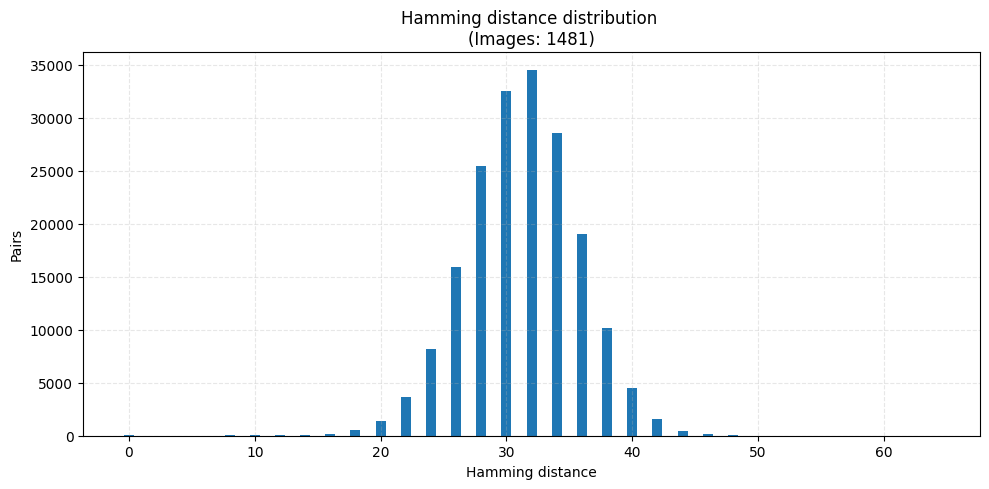

In [31]:
def hamming_dist_hex(h1_hex, h2_hex):
    return (int(h1_hex, 16) ^ int(h2_hex, 16)).bit_count()

dist_counter = Counter()
for klass, group in meta_df.groupby('klass'):
    ph_list =  ph_list = group["phash"].astype(str).tolist()
    if len(ph_list) < 2:
        continue
    for i, j in combinations(range(len(ph_list)), 2):
        d = hamming_dist_hex(ph_list[i], ph_list[j])
        dist_counter[d] += 1

max_d = 64
xs = list(range(0, max_d + 1))
ys = [dist_counter.get(d, 0) for d in xs]

plt.figure(figsize=(10, 5))
plt.bar(xs, ys)
plt.title(f"Hamming distance distribution \n(Images: {len(meta_df)})")
plt.xlabel("Hamming distance")
plt.ylabel("Pairs")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

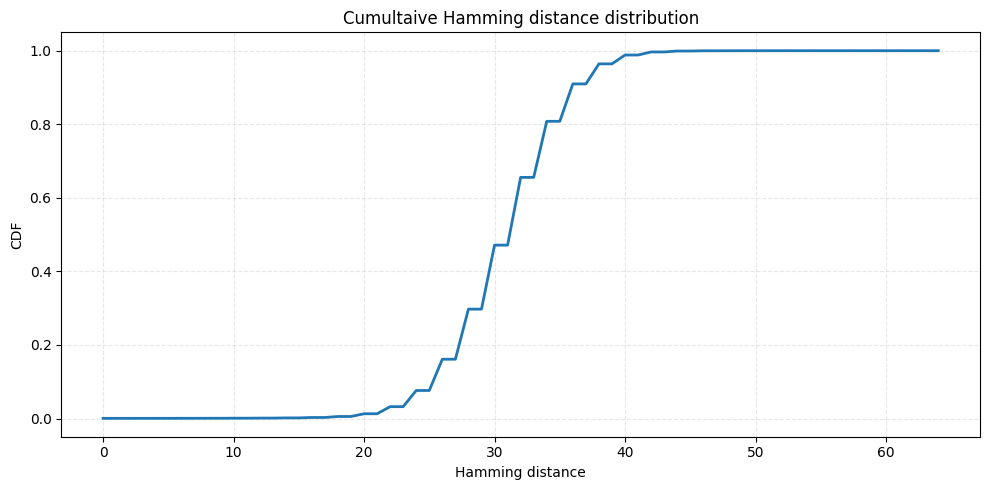

In [32]:
total_pairs = sum(ys)
cdf = np.cumsum(ys) / total_pairs

plt.figure(figsize=(10, 5))
plt.plot(xs, cdf, linewidth=2)
plt.title("Cumultaive Hamming distance distribution")
plt.xlabel("Hamming distance")
plt.ylabel("CDF")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion
The Hamming distance distribution forms a near-perfect bell curve centered around 30–32, which is typical for 64-bit perceptual hashes of visually distinct images.
The CDF confirms that almost all image pairs have distances above 20, indicating that the dataset contains few or no duplicates. Overall, the collection appears clean, diverse, and well-balanced in terms of visual similarity.

In [ ]:
3